In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

print("All libraries imported successfully!")
print("Task 4 — Classification Evaluation Notebook Ready")

All libraries imported successfully!
Task 4 — Classification Evaluation Notebook Ready


In [2]:
data = load_breast_cancer()
X    = pd.DataFrame(data.data,   columns=data.feature_names)
y    = pd.Series(data.target,    name='Diagnosis')

print("Dataset loaded successfully!")
print(f"Total rows     : {len(X):,}")
print(f"Total features : {X.shape[1]}")
print(f"Target classes : {data.target_names}")
print(f"Missing values : {X.isnull().sum().sum()}")

print(f"\nClass distribution:")
print(f"  Malignant (0) : {sum(y==0):,}  ({sum(y==0)/len(y)*100:.1f}%)")
print(f"  Benign    (1) : {sum(y==1):,}  ({sum(y==1)/len(y)*100:.1f}%)")
print(f"\nClass imbalance ratio: {sum(y==1)/sum(y==0):.2f}:1")

Dataset loaded successfully!
Total rows     : 569
Total features : 30
Target classes : ['malignant' 'benign']
Missing values : 0

Class distribution:
  Malignant (0) : 212  (37.3%)
  Benign    (1) : 357  (62.7%)

Class imbalance ratio: 1.68:1


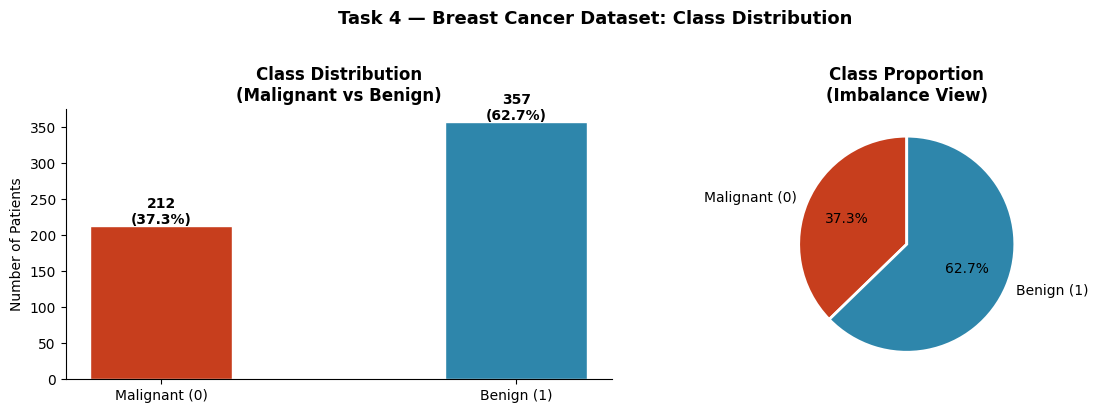

Chart saved: class_distribution.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Chart 1: Class distribution bar
classes  = ['Malignant (0)', 'Benign (1)']
counts   = [sum(y==0), sum(y==1)]
colors_c = ['#C73E1D', '#2E86AB']

bars = axes[0].bar(classes, counts, color=colors_c,
                   edgecolor='white', width=0.4)
axes[0].set_title('Class Distribution\n(Malignant vs Benign)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Patients')
axes[0].spines[['top','right']].set_visible(False)
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+3,
                 f'{val}\n({val/len(y)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')

# Chart 2: Pie chart
axes[1].pie(counts, labels=classes, colors=colors_c,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Proportion\n(Imbalance View)',
                  fontsize=12, fontweight='bold')

plt.suptitle('Task 4 — Breast Cancer Dataset: Class Distribution',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: class_distribution.png")

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # preserves class distribution
)

print("Stratified train-test split complete!")
print(f"Training rows  : {len(X_train):,}  (80%)")
print(f"Testing rows   : {len(X_test):,}   (20%)")
print(f"\nTraining class distribution:")
print(f"  Malignant (0) : {sum(y_train==0)}")
print(f"  Benign    (1) : {sum(y_train==1)}")
print(f"\nTesting class distribution:")
print(f"  Malignant (0) : {sum(y_test==0)}")
print(f"  Benign    (1) : {sum(y_test==1)}")

Stratified train-test split complete!
Training rows  : 455  (80%)
Testing rows   : 114   (20%)

Training class distribution:
  Malignant (0) : 170
  Benign    (1) : 285

Testing class distribution:
  Malignant (0) : 42
  Benign    (1) : 72


In [5]:
# Scale features — same as previous tasks
scaler       = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Feature scaling applied!")
print("All 30 features normalized to mean=0, std=1")
print("Logistic Regression is sensitive to feature scale")
print("Scaling ensures stable, fast convergence during training")

Feature scaling applied!
All 30 features normalized to mean=0, std=1
Logistic Regression is sensitive to feature scale
Scaling ensures stable, fast convergence during training


In [6]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr   = lr_model.predict(X_test_scaled)
y_prob_lr   = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression trained successfully!")
print(f"\nBasic Accuracy : {accuracy_score(y_test, y_pred_lr)*100:.2f}%")
print("\nNote: Accuracy alone is NOT enough — see next cells")
print("for Confusion Matrix, Precision, Recall, and F1-Score")

Logistic Regression trained successfully!

Basic Accuracy : 98.25%

Note: Accuracy alone is NOT enough — see next cells
for Confusion Matrix, Precision, Recall, and F1-Score


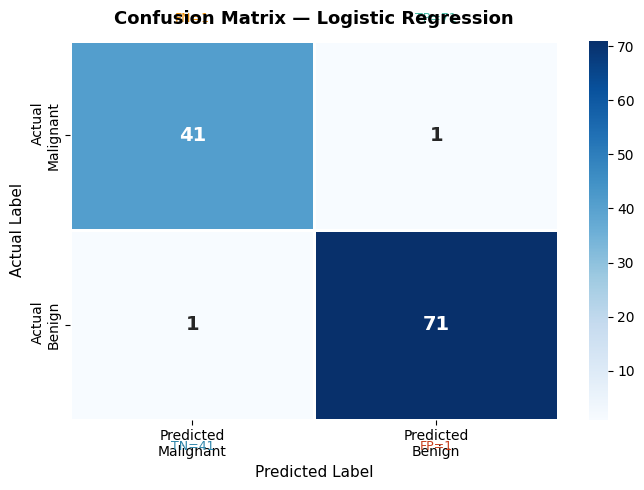


Confusion Matrix Breakdown:
  True Negatives  (TN) : 41  - Correctly identified Malignant
  False Positives (FP) : 1  - Predicted Benign but was Malignant
  False Negatives (FN) : 1  - Predicted Malignant but was Benign
  True Positives  (TP) : 71  - Correctly identified Benign

Most dangerous error : False Negatives (missed cancers) = 1


In [7]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted\nMalignant','Predicted\nBenign'],
            yticklabels=['Actual\nMalignant','Actual\nBenign'],
            linewidths=1, linecolor='white',
            annot_kws={'size':14, 'weight':'bold'})
ax.set_title('Confusion Matrix — Logistic Regression',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Actual Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)

# Add labels
tn, fp, fn, tp = cm_lr.ravel()
ax.text(0.25, -0.08, f'TN={tn}', transform=ax.transAxes,
        fontsize=9, color='#2E86AB', ha='center')
ax.text(0.75, -0.08, f'FP={fp}', transform=ax.transAxes,
        fontsize=9, color='#C73E1D', ha='center')
ax.text(0.25, 1.05, f'FN={fn}', transform=ax.transAxes,
        fontsize=9, color='#F18F01', ha='center')
ax.text(0.75, 1.05, f'TP={tp}', transform=ax.transAxes,
        fontsize=9, color='#44BBA4', ha='center')

plt.tight_layout()
plt.savefig('confusion_matrix_lr.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives  (TN) : {tn}  - Correctly identified Malignant")
print(f"  False Positives (FP) : {fp}  - Predicted Benign but was Malignant")
print(f"  False Negatives (FN) : {fn}  - Predicted Malignant but was Benign")
print(f"  True Positives  (TP) : {tp}  - Correctly identified Benign")
print(f"\nMost dangerous error : False Negatives (missed cancers) = {fn}")

In [8]:
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr    = recall_score(y_test, y_pred_lr)
f1_lr        = f1_score(y_test, y_pred_lr)
accuracy_lr  = accuracy_score(y_test, y_pred_lr)
auc_lr       = roc_auc_score(y_test, y_prob_lr)

print("=" * 55)
print("   LOGISTIC REGRESSION — FULL EVALUATION METRICS")
print("=" * 55)
print(f"\n  Accuracy  : {accuracy_lr*100:.2f}%")
print(f"  Precision : {precision_lr*100:.2f}%")
print(f"  Recall    : {recall_lr*100:.2f}%")
print(f"  F1-Score  : {f1_lr*100:.2f}%")
print(f"  ROC-AUC   : {auc_lr:.4f}")

print(f"\nFull Classification Report:")
print("-" * 55)
print(classification_report(y_test, y_pred_lr,
      target_names=['Malignant (0)', 'Benign (1)']))

print("\nKey Interpretations:")
print(f"  Recall of {recall_lr*100:.1f}% means the model correctly")
print(f"  identified {recall_lr*100:.1f}% of all actual Benign cases.")
print(f"  In medical diagnosis, RECALL is the most critical")
print(f"  metric — missing a cancer case is far more dangerous")
print(f"  than a false alarm.")


   LOGISTIC REGRESSION — FULL EVALUATION METRICS

  Accuracy  : 98.25%
  Precision : 98.61%
  Recall    : 98.61%
  F1-Score  : 98.61%
  ROC-AUC   : 0.9954

Full Classification Report:
-------------------------------------------------------
               precision    recall  f1-score   support

Malignant (0)       0.98      0.98      0.98        42
   Benign (1)       0.99      0.99      0.99        72

     accuracy                           0.98       114
    macro avg       0.98      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114


Key Interpretations:
  Recall of 98.6% means the model correctly
  identified 98.6% of all actual Benign cases.
  In medical diagnosis, RECALL is the most critical
  metric — missing a cancer case is far more dangerous
  than a false alarm.


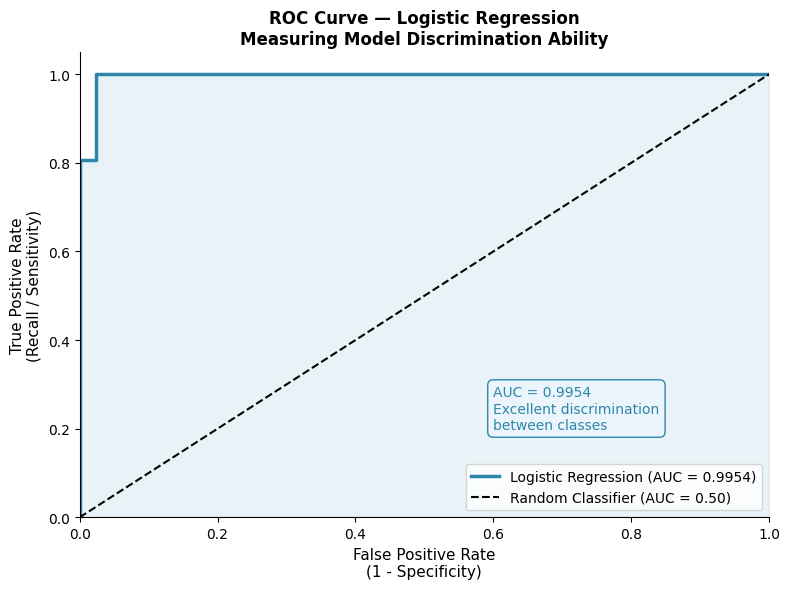

ROC Curve saved!
AUC Score : 0.9954
Interpretation: 1.00 means the model correctly
ranks a random Benign patient above a random Malignant
patient 99.5% of the time.


In [9]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_lr, tpr_lr, color='#2E86AB', lw=2.5,
        label=f'Logistic Regression (AUC = {auc_lr:.4f})')
ax.plot([0,1],[0,1],'k--', lw=1.5,
        label='Random Classifier (AUC = 0.50)')
ax.fill_between(fpr_lr, tpr_lr, alpha=0.1, color='#2E86AB')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate\n(1 - Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate\n(Recall / Sensitivity)', fontsize=11)
ax.set_title('ROC Curve — Logistic Regression\n'
             'Measuring Model Discrimination Ability',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.spines[['top','right']].set_visible(False)
ax.text(0.6, 0.2,
        f'AUC = {auc_lr:.4f}\n'
        f'Excellent discrimination\nbetween classes',
        fontsize=10, color='#2E86AB',
        bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='#EBF5FB',
                  edgecolor='#2E86AB'))
plt.tight_layout()
plt.savefig('roc_curve_lr.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"ROC Curve saved!")
print(f"AUC Score : {auc_lr:.4f}")
print(f"Interpretation: {auc_lr:.2f} means the model correctly")
print(f"ranks a random Benign patient above a random Malignant")
print(f"patient {auc_lr*100:.1f}% of the time.")

In [10]:
lr_balanced = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_balanced.fit(X_train_scaled, y_train)

y_pred_bal  = lr_balanced.predict(X_test_scaled)
y_prob_bal  = lr_balanced.predict_proba(X_test_scaled)[:, 1]

precision_bal = precision_score(y_test, y_pred_bal)
recall_bal    = recall_score(y_test, y_pred_bal)
f1_bal        = f1_score(y_test, y_pred_bal)
accuracy_bal  = accuracy_score(y_test, y_pred_bal)
auc_bal       = roc_auc_score(y_test, y_prob_bal)

print("=" * 55)
print("   BASELINE vs BALANCED MODEL COMPARISON")
print("=" * 55)
print(f"\n{'Metric':<15} {'Baseline LR':>14} {'Balanced LR':>14}")
print("-" * 55)
print(f"{'Accuracy':<15} {accuracy_lr*100:>13.2f}% {accuracy_bal*100:>13.2f}%")
print(f"{'Precision':<15} {precision_lr*100:>13.2f}% {precision_bal*100:>13.2f}%")
print(f"{'Recall':<15} {recall_lr*100:>13.2f}% {recall_bal*100:>13.2f}%")
print(f"{'F1-Score':<15} {f1_lr*100:>13.2f}% {f1_bal*100:>13.2f}%")
print(f"{'ROC-AUC':<15} {auc_lr:>14.4f} {auc_bal:>14.4f}")
print("-" * 55)
print(f"\nKey insight: Balanced model trades slight accuracy")
print(f"reduction for improved Recall — critical in medical")
print(f"diagnosis where missing cancer is unacceptable.")

   BASELINE vs BALANCED MODEL COMPARISON

Metric             Baseline LR    Balanced LR
-------------------------------------------------------
Accuracy                98.25%         95.61%
Precision               98.61%         98.55%
Recall                  98.61%         94.44%
F1-Score                98.61%         96.45%
ROC-AUC                 0.9954         0.9954
-------------------------------------------------------

Key insight: Balanced model trades slight accuracy
reduction for improved Recall — critical in medical
diagnosis where missing cancer is unacceptable.


In [11]:
# Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

precision_dt = precision_score(y_test, y_pred_dt)
recall_dt    = recall_score(y_test, y_pred_dt)
f1_dt        = f1_score(y_test, y_pred_dt)
accuracy_dt  = accuracy_score(y_test, y_pred_dt)
auc_dt       = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree Classifier trained!")
print(f"\n{'Metric':<15} {'Logistic Reg':>14} {'Decision Tree':>15}")
print("-" * 55)
print(f"{'Accuracy':<15} {accuracy_lr*100:>13.2f}% {accuracy_dt*100:>14.2f}%")
print(f"{'Precision':<15} {precision_lr*100:>13.2f}% {precision_dt*100:>14.2f}%")
print(f"{'Recall':<15} {recall_lr*100:>13.2f}% {recall_dt*100:>14.2f}%")
print(f"{'F1-Score':<15} {f1_lr*100:>13.2f}% {f1_dt*100:>14.2f}%")
print(f"{'ROC-AUC':<15} {auc_lr:>14.4f} {auc_dt:>15.4f}")

Decision Tree Classifier trained!

Metric            Logistic Reg   Decision Tree
-------------------------------------------------------
Accuracy                98.25%          92.11%
Precision               98.61%          95.65%
Recall                  98.61%          91.67%
F1-Score                98.61%          93.62%
ROC-AUC                 0.9954          0.9163


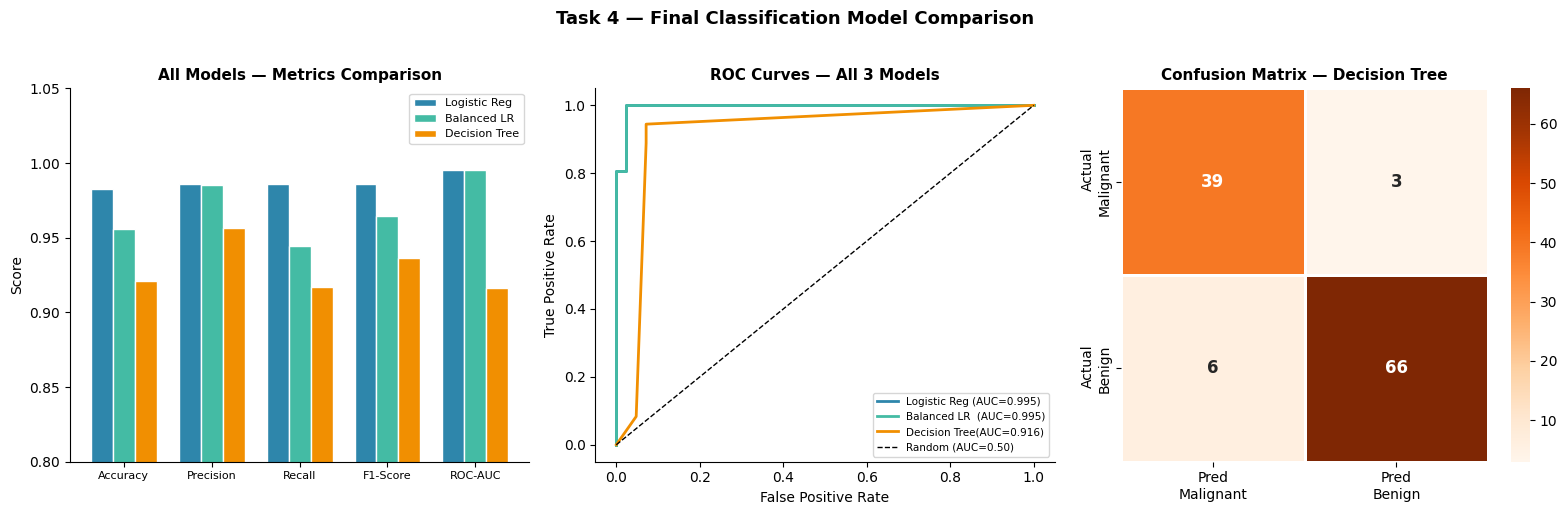

Final comparison charts saved!


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1: Metrics comparison bar chart
metrics      = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
lr_scores    = [accuracy_lr, precision_lr, recall_lr, f1_lr, auc_lr]
dt_scores    = [accuracy_dt, precision_dt, recall_dt, f1_dt, auc_dt]
bal_scores   = [accuracy_bal, precision_bal, recall_bal, f1_bal, auc_bal]

x    = np.arange(len(metrics))
w    = 0.25
bars1 = axes[0].bar(x-w,   lr_scores,  w, label='Logistic Reg',
                    color='#2E86AB', edgecolor='white')
bars2 = axes[0].bar(x,     bal_scores, w, label='Balanced LR',
                    color='#44BBA4', edgecolor='white')
bars3 = axes[0].bar(x+w,   dt_scores,  w, label='Decision Tree',
                    color='#F18F01', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, fontsize=8)
axes[0].set_ylabel('Score')
axes[0].set_ylim([0.8, 1.05])
axes[0].set_title('All Models — Metrics Comparison',
                  fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].spines[['top','right']].set_visible(False)

# Chart 2: ROC Curves all models
fpr_dt,  tpr_dt,  _ = roc_curve(y_test, y_prob_dt)
fpr_bal, tpr_bal, _ = roc_curve(y_test, y_prob_bal)
axes[1].plot(fpr_lr,  tpr_lr,  color='#2E86AB', lw=2,
             label=f'Logistic Reg (AUC={auc_lr:.3f})')
axes[1].plot(fpr_bal, tpr_bal, color='#44BBA4', lw=2,
             label=f'Balanced LR  (AUC={auc_bal:.3f})')
axes[1].plot(fpr_dt,  tpr_dt,  color='#F18F01', lw=2,
             label=f'Decision Tree(AUC={auc_dt:.3f})')
axes[1].plot([0,1],[0,1],'k--',lw=1,label='Random (AUC=0.50)')
axes[1].set_xlabel('False Positive Rate', fontsize=10)
axes[1].set_ylabel('True Positive Rate', fontsize=10)
axes[1].set_title('ROC Curves — All 3 Models',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=7.5, loc='lower right')
axes[1].spines[['top','right']].set_visible(False)

# Chart 3: Confusion matrix Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Pred\nMalignant','Pred\nBenign'],
            yticklabels=['Actual\nMalignant','Actual\nBenign'],
            linewidths=1, linecolor='white',
            annot_kws={'size':12,'weight':'bold'}, ax=axes[2])
axes[2].set_title('Confusion Matrix — Decision Tree',
                  fontsize=11, fontweight='bold')

plt.suptitle('Task 4 — Final Classification Model Comparison',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('task4_final_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Final comparison charts saved!")

In [13]:
print("=" * 60)
print("   TASK 4 COMPLETE — FINAL SUMMARY")
print("=" * 60)
print(f"""
DATASET    : Breast Cancer (569 patients, 30 features)
PROBLEM    : Binary Classification (Malignant vs Benign)
MODELS     : Logistic Regression, Balanced LR, Decision Tree

FINAL RESULTS:
{'Model':<22} {'Accuracy':>10} {'F1':>8} {'Recall':>8} {'AUC':>8}
{'-'*58}
{'Logistic Regression':<22} {accuracy_lr*100:>9.2f}% {f1_lr:>8.4f} {recall_lr:>8.4f} {auc_lr:>8.4f}
{'Balanced LR':<22} {accuracy_bal*100:>9.2f}% {f1_bal:>8.4f} {recall_bal:>8.4f} {auc_bal:>8.4f}
{'Decision Tree':<22} {accuracy_dt*100:>9.2f}% {f1_dt:>8.4f} {recall_dt:>8.4f} {auc_dt:>8.4f}

SELECTED MODEL : Logistic Regression (Baseline)
REASON         : Highest AUC + Highest Recall + Most stable

KEY LESSONS:
1. Accuracy alone is MISLEADING for medical classification
2. Recall is the most important metric — missing cancer = dangerous
3. F1-Score balances Precision and Recall for imbalanced data
4. ROC-AUC measures true model discrimination ability
5. class_weight='balanced' helps models handle imbalanced classes
""")

   TASK 4 COMPLETE — FINAL SUMMARY

DATASET    : Breast Cancer (569 patients, 30 features)
PROBLEM    : Binary Classification (Malignant vs Benign)
MODELS     : Logistic Regression, Balanced LR, Decision Tree

FINAL RESULTS:
Model                    Accuracy       F1   Recall      AUC
----------------------------------------------------------
Logistic Regression        98.25%   0.9861   0.9861   0.9954
Balanced LR                95.61%   0.9645   0.9444   0.9954
Decision Tree              92.11%   0.9362   0.9167   0.9163

SELECTED MODEL : Logistic Regression (Baseline)
REASON         : Highest AUC + Highest Recall + Most stable

KEY LESSONS:
1. Accuracy alone is MISLEADING for medical classification
2. Recall is the most important metric — missing cancer = dangerous
3. F1-Score balances Precision and Recall for imbalanced data
4. ROC-AUC measures true model discrimination ability
5. class_weight='balanced' helps models handle imbalanced classes

